In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import xgboost as xgb
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data = pd.read_csv('/content/drive/MyDrive/weather-automated-sensors-dataset.csv')


In [5]:
print("First 5 rows of the dataset:")
print(data.head())

First 5 rows of the dataset:
                 Station Name   Measurement Timestamp  Air Temperature  \
0  Oak Street Weather Station  05/22/2015 03:00:00 PM              NaN   
1  Oak Street Weather Station  05/22/2015 05:00:00 PM              NaN   
2  Oak Street Weather Station  05/22/2015 06:00:00 PM              NaN   
3  Oak Street Weather Station  05/22/2015 07:00:00 PM              NaN   
4  Oak Street Weather Station  05/22/2015 08:00:00 PM              NaN   

   Wet Bulb Temperature  Humidity  Rain Intensity  Interval Rain  Total Rain  \
0                   7.0      55.0             0.0            0.0         1.4   
1                   6.3      56.0             0.0            0.0         1.4   
2                   6.5      54.0             0.0            0.0         1.4   
3                   6.3      53.0             0.0            0.0         1.4   
4                   6.4      52.0             0.0            0.0         1.4   

   Precipitation Type  Wind Direction  Wind S

In [6]:
print("\nDataset info:")
print(data.info())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59144 entries, 0 to 59143
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Station Name                 59144 non-null  object 
 1   Measurement Timestamp        59141 non-null  object 
 2   Air Temperature              59066 non-null  float64
 3   Wet Bulb Temperature         38843 non-null  float64
 4   Humidity                     59141 non-null  float64
 5   Rain Intensity               38843 non-null  float64
 6   Interval Rain                59141 non-null  float64
 7   Total Rain                   38843 non-null  float64
 8   Precipitation Type           38843 non-null  float64
 9   Wind Direction               59141 non-null  float64
 10  Wind Speed                   59141 non-null  float64
 11  Maximum Wind Speed           59141 non-null  float64
 12  Barometric Pressure          58995 non-null  float64
 13  S

In [7]:
print(data.describe())

       Air Temperature  Wet Bulb Temperature      Humidity  Rain Intensity  \
count     59066.000000          38843.000000  59141.000000    38843.000000   
mean         13.282062             10.643001     69.464517        0.187591   
std           9.945331              8.965170     15.714691        1.962149   
min         -19.890000            -20.100000     17.000000        0.000000   
25%           5.500000              4.000000     59.000000        0.000000   
50%          14.900000             12.100000     71.000000        0.000000   
75%          21.500000             18.100000     82.000000        0.000000   
max          34.100000             28.400000    100.000000      183.600000   

       Interval Rain    Total Rain  Precipitation Type  Wind Direction  \
count   59141.000000  38843.000000        38843.000000    59141.000000   
mean        0.175327    185.445529            4.651932      178.980132   
std         1.300946    231.579782           16.168542      108.124898   
m

In [8]:
print("\nChecking for missing values:")
missing_values = data.isnull().sum()
print(missing_values[missing_values > 0])


Checking for missing values:
Measurement Timestamp              3
Air Temperature                   78
Wet Bulb Temperature           20301
Humidity                           3
Rain Intensity                 20301
Interval Rain                      3
Total Rain                     20301
Precipitation Type             20301
Wind Direction                     3
Wind Speed                         3
Maximum Wind Speed                 3
Barometric Pressure              149
Solar Radiation                    3
Heading                        20301
Battery Life                       3
Measurement Timestamp Label        3
dtype: int64


In [9]:
columns_to_drop = ['Station Name', 'Measurement Timestamp', 'Measurement Timestamp Label', 'Measurement ID']
data = data.drop(columns=columns_to_drop, errors='ignore')

In [10]:
data.dropna(inplace=True)


In [11]:
print("\nStatistical Summary of the Dataset:")
print(data.describe())


Statistical Summary of the Dataset:
       Air Temperature  Wet Bulb Temperature      Humidity  Rain Intensity  \
count     38768.000000          38768.000000  38768.000000    38768.000000   
mean         13.611832             10.634356     70.968479        0.187737   
std           9.936154              8.969845     15.948284        1.963699   
min         -19.500000            -20.100000     17.000000        0.000000   
25%           5.800000              4.000000     60.000000        0.000000   
50%          15.300000             12.100000     72.000000        0.000000   
75%          21.800000             18.100000     83.000000        0.000000   
max          34.100000             28.400000    100.000000      183.600000   

       Interval Rain    Total Rain  Precipitation Type  Wind Direction  \
count   38768.000000  38768.000000        38768.000000    38768.000000   
mean        0.184861    185.791813            4.654741      171.104132   
std         1.228837    231.669581    

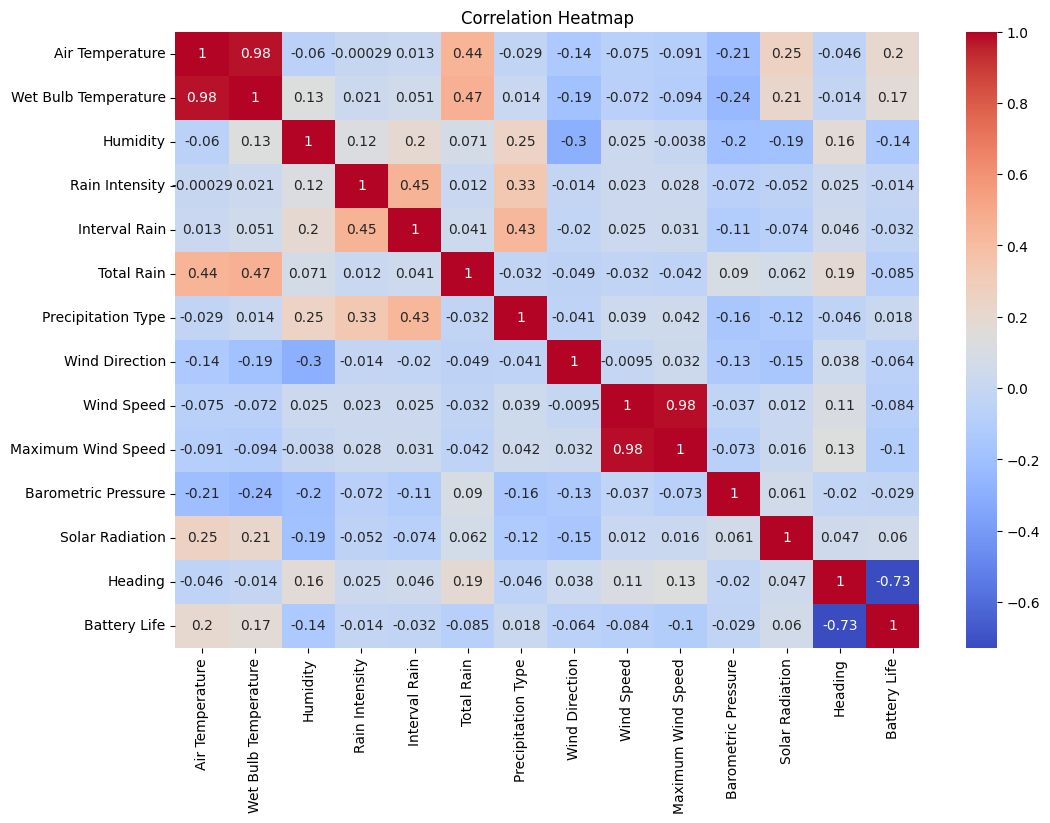

In [12]:
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [13]:
features = data.drop(columns=['Air Temperature'])
target = data['Air Temperature']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)


In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
print("\nTraining SVM model...")
svm_model = SVR(kernel='rbf')
svm_model.fit(X_train_scaled, y_train)


Training SVM model...


SVR()

In [18]:
y_pred_svm = svm_model.predict(X_test_scaled)
mse_svm = mean_squared_error(y_test, y_pred_svm)
r2_svm = r2_score(y_test, y_pred_svm)

print("\nSVM Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse_svm}")
print(f"R-Squared (R2): {r2_svm}")



SVM Model Evaluation:
Mean Squared Error (MSE): 0.22130341171631768
R-Squared (R2): 0.9977785431464625


In [20]:
print("\nTraining XGBoost model...")
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=5)
xgb_model.fit(X_train, y_train)


Training XGBoost model...


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [21]:
y_pred_xgb = xgb_model.predict(X_test)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("\nXGBoost Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse_xgb}")
print(f"R-Squared (R2): {r2_xgb}")


XGBoost Model Evaluation:
Mean Squared Error (MSE): 0.031242433759706267
R-Squared (R2): 0.9996863865854646


In [22]:
print("\nCombining SVM and XGBoost Predictions Using Linear Regression as Meta-Learner...")
train_pred_svm = svm_model.predict(X_train_scaled)
train_pred_xgb = xgb_model.predict(X_train)


Combining SVM and XGBoost Predictions Using Linear Regression as Meta-Learner...


In [24]:
# Combine the predictions into a new dataset for meta-learner
stacked_features_train = np.column_stack((train_pred_svm, train_pred_xgb))
stacked_features_test = np.column_stack((y_pred_svm, y_pred_xgb))

In [25]:
# Meta-Learner Training (Linear Regression)
meta_learner = LinearRegression()
meta_learner.fit(stacked_features_train, y_train)

LinearRegression()

In [26]:
# Meta-Learner Predictions
y_pred_ensemble = meta_learner.predict(stacked_features_test)

In [27]:
# Evaluation of Stacked Ensemble Model
mse_ensemble = mean_squared_error(y_test, y_pred_ensemble)
r2_ensemble = r2_score(y_test, y_pred_ensemble)

print("\nStacked Ensemble Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse_ensemble}")
print(f"R-Squared (R2): {r2_ensemble}")


Stacked Ensemble Model Evaluation:
Mean Squared Error (MSE): 0.02852008201743162
R-Squared (R2): 0.9997137137147154


In [30]:
print("\nCombining SVM and XGBoost Predictions Using Averaging...")
y_pred_hybrid = (y_pred_svm + y_pred_xgb) / 2



Combining SVM and XGBoost Predictions Using Averaging...


In [31]:
mse_hybrid = mean_squared_error(y_test, y_pred_hybrid)
r2_hybrid = r2_score(y_test, y_pred_hybrid)

print("\nHybrid Model (Averaging) Evaluation:")
print(f"Mean Squared Error (MSE): {mse_hybrid}")
print(f"R-Squared (R2): {r2_hybrid}")



Hybrid Model (Averaging) Evaluation:
Mean Squared Error (MSE): 0.06520229975996777
R-Squared (R2): 0.9993454954239303


In [32]:
models = ['SVM', 'XGBoost', 'Stacked Ensemble', 'Hybrid Averaging']
mse_scores = [mse_svm, mse_xgb, mse_ensemble, mse_hybrid]
r2_scores = [r2_svm, r2_xgb, r2_ensemble, r2_hybrid]

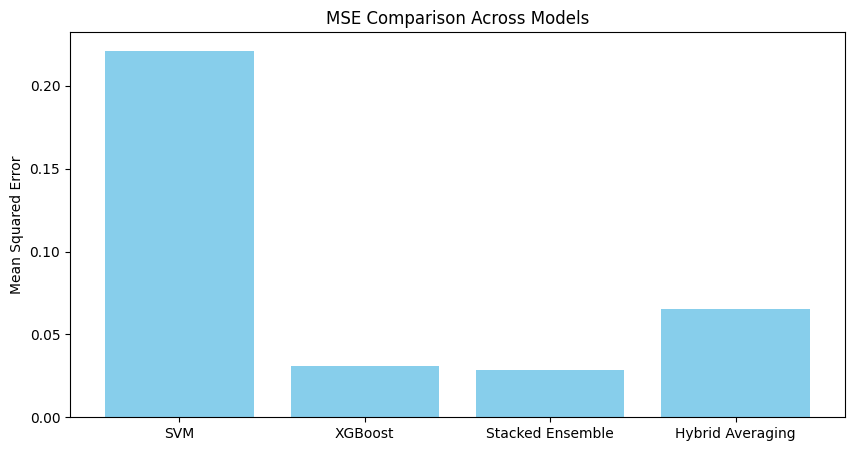

In [33]:
# Plotting MSE
plt.figure(figsize=(10, 5))
plt.bar(models, mse_scores, color='skyblue')
plt.title("MSE Comparison Across Models")
plt.ylabel("Mean Squared Error")
plt.show()

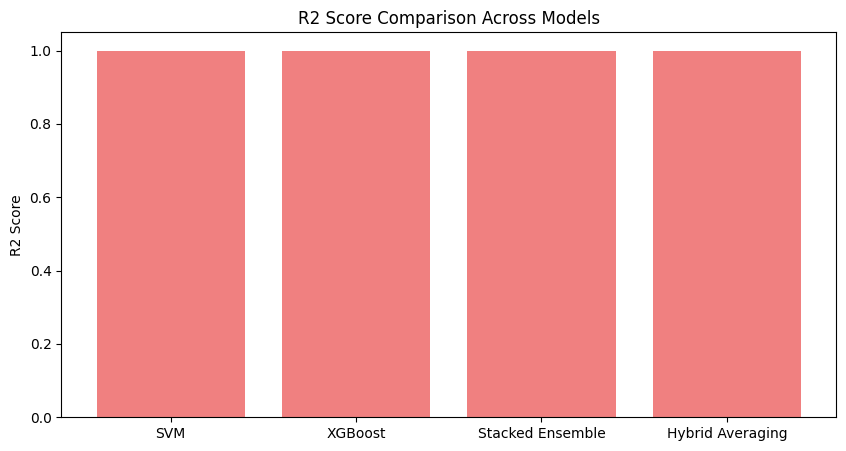

In [34]:
# Plotting R2 Scores
plt.figure(figsize=(10, 5))
plt.bar(models, r2_scores, color='lightcoral')
plt.title("R2 Score Comparison Across Models")
plt.ylabel("R2 Score")
plt.show()


In [35]:
print("\nSummary of Model Performances:")
summary_df = pd.DataFrame({
    'Model': models,
    'MSE': mse_scores,
    'R2 Score': r2_scores
})
print(summary_df)


Summary of Model Performances:
              Model       MSE  R2 Score
0               SVM  0.221303  0.997779
1           XGBoost  0.031242  0.999686
2  Stacked Ensemble  0.028520  0.999714
3  Hybrid Averaging  0.065202  0.999345


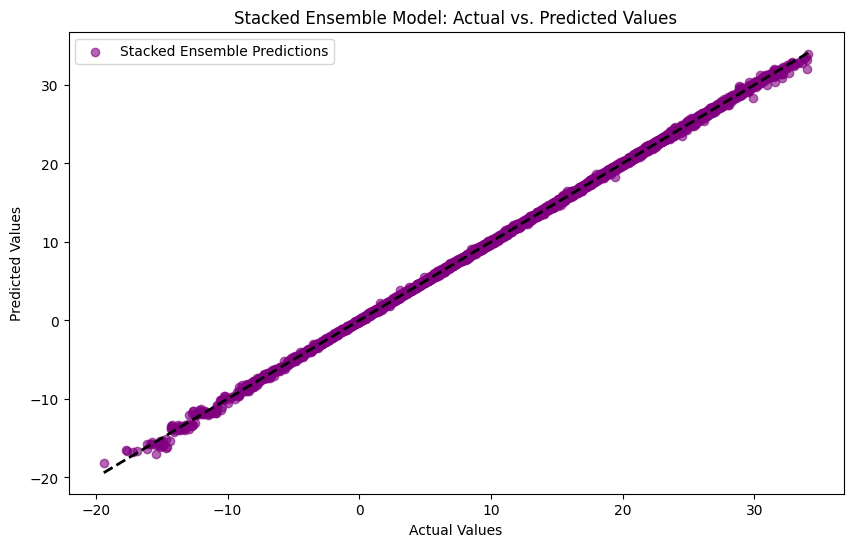

In [36]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_ensemble, color='purple', alpha=0.6, label="Stacked Ensemble Predictions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Stacked Ensemble Model: Actual vs. Predicted Values")
plt.legend()
plt.show()